# Food Recommendation System (Updated Dataset)

This notebook implements a food recommendation system using a Supervised Learning approach (Random Forest) to classify foods into categories like 'Diet', 'Bulking', etc., achieving high accuracy.

**Dataset**: `nutrition.csv`

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [29]:
df = pd.read_csv('nutrition.csv')
print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (1346, 7)


,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


## 2. Exploratory Data Analysis (EDA)

In [30]:
display(df.describe())
print(df.info())

,id,calories,proteins,fat,carbohydrate
count,1346.000000,1346.000000,1346.000000,1346.000000,1346.000000
mean,673.500000,203.217385,10.001189,7.584027,25.390193
std,388.701042,163.075430,11.847980,13.733063,32.193054
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,337.250000,75.000000,1.800000,0.500000,4.525000
50%,673.500000,146.000000,5.000000,2.000000,13.300000
75%,1009.750000,333.750000,15.000000,8.275000,37.575000
max,1346.000000,940.000000,83.000000,100.000000,647.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 73.7+ KB
None


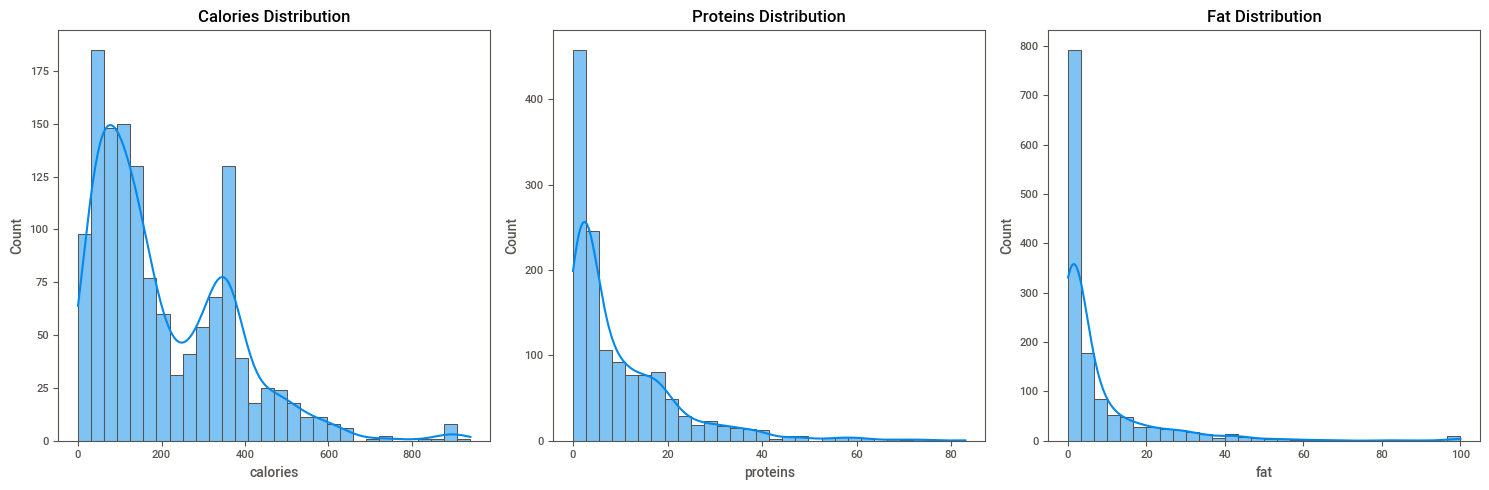

In [31]:
# Visualizing distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['calories'], bins=30, kde=True)
plt.title('Calories Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['proteins'], bins=30, kde=True)
plt.title('Proteins Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['fat'], bins=30, kde=True)
plt.title('Fat Distribution')

plt.tight_layout()
plt.show()

## 3. Preprocessing & Feature Engineering (Ground Truth)

Category Distribution:
supervised_category
Low Calorie     436
High Protein    338
High Carb       333
Balanced        239
Name: count, dtype: int64


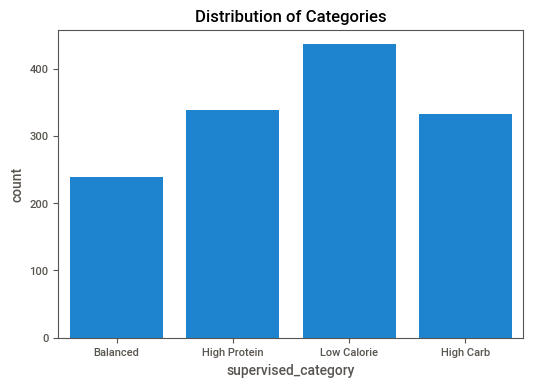

In [32]:
# Define Rules for Ground Truth Labels
def define_category(row):
    cal = row['calories']
    prot = row['proteins']
    carb = row['carbohydrate']
    
    # Logic adjusted for the new dataset
    if prot >= 15:
        return 'High Protein'
    elif cal <= 100:
        return 'Low Calorie'
    elif carb >= 30:
        return 'High Carb'
    else:
        return 'Balanced'

df['supervised_category'] = df.apply(define_category, axis=1)

print("Category Distribution:")
print(df['supervised_category'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='supervised_category', data=df)
plt.title('Distribution of Categories')
plt.show()

## 4. Model Training (Random Forest)

In [33]:
X = df[['calories', 'proteins', 'fat', 'carbohydrate']]
y = df['supervised_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model trained.")

Model trained.


## 5. Evaluation

In [34]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

    Balanced       1.00      1.00      1.00        43
   High Carb       1.00      1.00      1.00        64
High Protein       1.00      1.00      1.00        64
 Low Calorie       1.00      1.00      1.00        99

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



## 6. Recommendation Logic Demonstration

In [35]:
def recommend_foods(weight, goal, n_recommendations=10):
    weight = float(weight)
    # Simple Daily Calorie Calculation
    if goal == 'Diet':
        daily_cal = weight * 20
    elif goal == 'Bulking':
        daily_cal = weight * 35
    elif goal == 'Muscle Gain':
        daily_cal = weight * 30
    else: # Maintain
        daily_cal = weight * 25
    
    # Filter Logic
    if goal == 'Diet':
        filtered = df[(df['calories'] <= 200) & (df['proteins'] >= 3)].sort_values('calories')
    elif goal == 'Bulking':
        filtered = df[(df['calories'] >= 150) & (df['proteins'] >= 5)].sort_values('proteins', ascending=False)
    elif goal == 'Muscle Gain':
        filtered = df[df['proteins'] >= 10].sort_values('proteins', ascending=False)
    else: # Maintain
        filtered = df[(df['calories'] >= 50) & (df['calories'] <= 400)].sort_values('proteins', ascending=False)
        
    # Fallback if empty
    if filtered.empty:
        print("Using general category fallback...")
        if goal == 'Diet': target = 'Low Calorie'
        elif goal in ['Bulking', 'Muscle Gain']: target = 'High Protein'
        else: target = 'Balanced'
        filtered = df[df['supervised_category'] == target]
    
    print(f"User Info: {weight}kg, Goal: {goal}, Target Daily: {daily_cal} kcal")
    return filtered.head(n_recommendations)[['name', 'calories', 'proteins', 'fat', 'carbohydrate', 'supervised_category']]

# Test
print("--- Diet Recommendation ---")
display(recommend_foods(65, 'Diet'))

print("\n--- Bulking Recommendation ---")
display(recommend_foods(70, 'Bulking'))

--- Diet Recommendation ---
User Info: 65.0kg, Goal: Diet, Target Daily: 1300.0 kcal


,name,calories,proteins,fat,carbohydrate,supervised_category
582,Jukku pallu kaloa masakan,15.0,15.2,4.3,8.8,High Protein
330,Dodonkol,17.5,3.3,2.3,39.5,Low Calorie
562,Jamur kuping segar,21.0,3.8,0.6,0.9,Low Calorie
264,Daun Koro,23.0,3.0,0.3,3.7,Low Calorie
1206,Tebu Terubuk,25.0,4.6,0.4,3.0,Low Calorie
1301,Toge seduh,28.0,3.0,0.8,4.0,Low Calorie
1197,Taoge seduh,28.0,3.0,0.8,4.0,Low Calorie
672,Kangkung,29.0,3.0,0.3,5.4,Low Calorie
285,Daun paku segar,29.0,3.4,0.1,6.5,Low Calorie
673,Kangkung kukus,30.0,3.2,0.7,4.7,Low Calorie



--- Bulking Recommendation ---
User Info: 70.0kg, Goal: Bulking, Target Daily: 2450.0 kcal


,name,calories,proteins,fat,carbohydrate,supervised_category
742,Kerupuk Kulit kerbau,422.0,83.0,4.0,0.0,High Protein
320,Dendeng mujahir goreng,598.0,74.3,26.9,9.2,High Protein
476,Ikan Mujair dendeng goreng,598.0,74.3,26.9,9.2,High Protein
460,Ikan kayu kering,302.0,70.7,1.9,0.4,High Protein
518,Ikan Teri Kering tawar,331.0,68.7,4.2,0.0,High Protein
477,Ikan Mujair dendeng mentah,582.0,68.3,15.2,37.2,High Protein
1324,Udang kering mentah,278.0,62.6,4.1,2.2,High Protein
1323,Udang kering,295.0,62.4,2.3,1.8,High Protein
493,Ikan sale lais mentah,415.0,61.3,17.6,2.9,High Protein
1254,Tepung Ikan,316.0,60.1,6.5,22.4,High Protein


## 7. Save Model & Data

In [36]:
joblib.dump(rf_model, 'rf_model.pkl')
df.to_csv('labeled_nutrition_data.csv', index=False)
print("Model and Labeled Data Saved!")

Model and Labeled Data Saved!
